# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PyCalib, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [111]:
!where python

c:\Users\deyve\Documents\PySonoGen\.venv\Scripts\python.exe
C:\Users\deyve\AppData\Local\Microsoft\WindowsApps\python.exe


# 2. BrainGlobe

In [112]:
from brainglobe_atlasapi import BrainGlobeAtlas
from brainglobe_atlasapi import show_atlases
from pprint import pprint

import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2.1. Check atlas disponibilites

In [113]:
show_atlases()

╭───────────────────────────────── Brainglobe Atlases ─────────────────────────────────╮
│                                                                           Latest     │
│  Name                              Downloaded  Updated  Local version    version     │
│  allen_mouse_25um                      ✔          ✔          1.2           1.2       │
│  whs_sd_rat_39um                       ✔          ✔          1.2           1.2       │
│  admba_3d_e11_5_mouse_16um                                                 1.1       │
│  admba_3d_e13_5_mouse_16um                                                 1.1       │
│  admba_3d_e15_5_mouse_16um                                                 1.1       │
│  admba_3d_e18_5_mouse_16um                                                 1.1       │
│  admba_3d_p14_mouse_16.752um                                               1.1       │
│  admba_3d_p28_mouse_16.752um                                               1.1       │
│  admba_3d_p4_mouse_16.752um                                                1.1       │
│  admba_3d_p56_mouse_25um                                                   1.1       │
│  allen_cord_20um                                                           1.1       │
│  allen_human_500um                                                         1.0       │
│  allen_mouse_100um                                                         1.2       │
│  allen_mouse_10um                                                          1.2       │
│  allen_mouse_50um                                                          1.2       │
│  allen_mouse_bluebrain_barrels_1…                                          1.0       │
│  allen_mouse_bluebrain_barrels_2…                                          1.0       │
│  australian_mouse_15um                                                     1.0       │
│  azba_zfish_4um                                                            1.2       │
│  columbia_cuttlefish_50um                                                  1.0       │
│  csl_cat_500um                                                             1.0       │
│  eurasian_blackcap_25um                                                    1.2       │
│  example_mouse_100um                                                       1.2       │
│  kim_dev_mouse_e11-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e11-5_mri-adc_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-dwi_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-fa_31.5…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-t2_31.5…                                          1.3       │
│  kim_dev_mouse_e13-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e13-5_mri-adc_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-dwi_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-fa_34um                                           1.3       │
│  kim_dev_mouse_e13-5_mri-t2_34um                                           1.3       │
│  kim_dev_mouse_e15-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e15-5_mri-adc_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-dwi_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-fa_37.5…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-mtr_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-t2_37.5…                                          1.3       │
│  kim_dev_mouse_e18-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e18-5_mri-adc_40um                                          1.3       │
│  kim_dev_mouse_e18-5_mri-dwi_40um                                          1.3    

## 2.2. Select an atlas

Let's select one (if atlas is not previously downloaded, one needs internet to download it):

In [114]:
bg_atlas = BrainGlobeAtlas("whs_sd_rat_39um", check_latest=False)

### 2.2.1. Metadata

All atlases have a standard set of metatata describing their source, species, resolution, etc

In [115]:
bg_atlas.metadata

{'name': 'whs_sd_rat',
 'citation': 'Kleven et al 2023, https://doi.org/10.1038/s41592-023-02034-3',
 'atlas_link': 'https://www.nitrc.org/projects/whs-sd-atlas',
 'species': 'Rattus norvegicus',
 'symmetric': False,
 'resolution': [39.0, 39.0, 39.0],
 'orientation': 'asr',
 'version': '1.2',
 'shape': [1024, 512, 512],
 'trasform_to_bg': [[0.0, -1.0, 0.0, 39936.0],
  [0.0, 0.0, -1.0, 19968.0],
  [-1.0, 0.0, 0.0, 19968.0],
  [0.0, 0.0, 0.0, 1.0]],
 'additional_references': [],
 'atlas_packager': 'Harry Carey, University of Oslo, Norway, harry.carey@medisin.uio.no'}

In [116]:
bg_atlas.space

<BGSpace AnatomicalSpace object>
origin: ('Anterior', 'Superior', 'Right')
sections: ('Frontal plane', 'Horizontal plane', 'Sagittal plane')
shape: (1024, 512, 512)

### 2.2.2. Type of information

Other information:

In [117]:
annatomical_ref_stack = bg_atlas.reference
print(annatomical_ref_stack.shape)

## # Visualize the reference stack
# plotter = pv.Plotter(notebook=False)

# plotter.add_volume(
#     annatomical_ref_stack,
#     cmap="gray",
#     opacity="sigmoid",
#     show_scalar_bar=True,
# )
# plotter.add_axes()
# plotter.show() 


(1024, 512, 512)


In [118]:
annotations_stack = bg_atlas.annotation
print(annotations_stack.shape)

(1024, 512, 512)


In [119]:
hemispheres_stack = bg_atlas.hemispheres
print(hemispheres_stack.shape)

(1024, 512, 512)


### 2.2.3. Regions hierarchy:

The atlas comes with the description of a hierarchy of brain structures. To have an overview:

``` bg_atlas.structures ```

The structures attribute is a custom dictionary that can be queried by region number or acronym, and contains all the information for a given structure

In [120]:
bg_atlas.structures

root (10000)
├── Brain (1000)
│   ├── GM (1013)
│   │   ├── Dien (1080)
│   │   │   ├── HY (1034)
│   │   │   │   └── HTh-u (48)
│   │   │   ├── PreT (1096)
│   │   │   │   ├── PRT (94)
│   │   │   │   └── Sag (163)
│   │   │   ├── Thal-D (1084)
│   │   │   │   ├── ANT (1085)
│   │   │   │   │   ├── AD (213)
│   │   │   │   │   ├── AM (254)
│   │   │   │   │   ├── AV (1086)
│   │   │   │   │   │   ├── AV-dm (214)
│   │   │   │   │   │   └── AV-vl (215)
│   │   │   │   │   ├── IAM (255)
│   │   │   │   │   ├── IMD (260)
│   │   │   │   │   ├── PIL (208)
│   │   │   │   │   ├── PT (211)
│   │   │   │   │   ├── PV (242)
│   │   │   │   │   └── SPF (278)
│   │   │   │   ├── ILM (1092)
│   │   │   │   │   ├── CL (248)
│   │   │   │   │   ├── CM (247)
│   │   │   │   │   ├── Eth (282)
│   │   │   │   │   ├── PCN (246)
│   │   │   │   │   └── PF (267)
│   │   │   │   ├── LD (1095)
│   │   │   │   │   ├── DLG (205)
│   │   │   │   │   ├── LD-dm (228)
│   │   │   │   │   └── LD-vl (229)
│   │  

In [121]:
for id_region, region in bg_atlas.structures.items():  
     # Check if the structure has no parent (or parent is the root)
        print(f"{id_region}: {region['name'], region['acronym']}")

10000: ('Root', 'root')
1000: ('Brain', 'Brain')
1001: ('White matter', 'wmt')
1050: ('Olfactory white matter', 'olf')
180: ('lateral olfactory tract', 'lot')
67: ('corpus callosum and associated subcortical white matter', 'cc-ec-cing-dwm')
1002: ('Anterior commissure', 'ac')
36: ('anterior commissure, anterior limb', 'aca')
37: ('anterior commissure, posterior limb', 'acp')
73: ('anterior commissure, intrabulbar part', 'aci')
1003: ('Hippocampal white matter', 'hiw')
6: ('alveus of the hippocampus', 'alv')
38: ('ventral hippocampal commissure', 'vhc')
52: ('fornix', 'f')
59: ('fimbria of the hippocampus', 'fi')
1004: ('Corticofugal pathways', 'cfp')
1: ('corticofugal tract and corona radiata', 'ic-cp-lfp-py')
85: ('pyramidal decussation', 'pyx')
1005: ('Medial lemniscus', 'ml')
34: ('medial lemniscus, unspecified', 'ml-u')
84: ('medial lemniscus decussation', 'mlx')
1006: ('Thalamic tracts', 'tht')
1051: ('External medullary lamina', 'eml')
249: ('external medullary lamina, unspecifie

## 2.3. Visualize brain and regions

Select your areas

In [122]:
Full_Brain_name = "root"
print(bg_atlas.structures[Full_Brain_name]['name'])

Brain_Reg_M1_name = 'M1' # Primary Motor Cortex ('M1' in rat but 'MO' in mouse)
print(bg_atlas.structures[Brain_Reg_M1_name]['name'])

Brain_Reg_SO_name   = "S1-hl"  # Primary Somatosensory Cortex (S1) - hindlimb region ("S1-hl" in rat but "SSp-ll"  in mouse)
print(bg_atlas.structures[Brain_Reg_SO_name]['name'])

Root
Primary motor area
Primary somatosensory area, hindlimb representation


Create pyvista object from object mesh

In [123]:
pv_Full_Brain   = pv.read(bg_atlas.structures[Full_Brain_name]['mesh_filename'])  # the entire brain surface :contentReference[oaicite:0]{index=0}
pv_Brain_Reg_M1 = pv.read(bg_atlas.structures[Brain_Reg_M1_name]['mesh_filename'])  # Primary Motor Cortex ('M1' in rat but 'MO' in mouse)
pv_Brain_Reg_SO = pv.read(bg_atlas.structures[Brain_Reg_SO_name]['mesh_filename'])  # Primary Somatosensory Cortex (S1) - hindlimb region ("S1-hl" in rat but "SSp-ll"  in mouse)

Now create a plotter and add each mesh with its colors

In [124]:
def plot_brain(brain_mesh, region1, region2, region1_name, region2_name): 
    brain_plotter = pv.Plotter(window_size=[1024, 768], title=f"Rat atlas", notebook=True)
    brain_plotter.add_mesh(brain_mesh,   color="lightgrey", opacity=0.2,    label="brain")
    brain_plotter.add_mesh(region1,  color="tomato",     opacity=0.6,    label=region1_name )
    brain_plotter.add_mesh(region2,  color="blue",     opacity=0.6,    label=region2_name )
    brain_plotter.add_axes()              # show XYZ axes
    brain_plotter.show_grid()             # show grid
    brain_plotter.add_legend(loc = 'upper left')             # show legend
    brain_plotter.camera_position = [(-36287.07522645855, -30715.658288305676, -47985.07664367932),
    (19987.5, 9048.0, 9711.0),
    (0.367051931123524, -0.893723057061909, 0.25793793271717014)]
    # to show the plot in Jupyter Notebook
    return brain_plotter

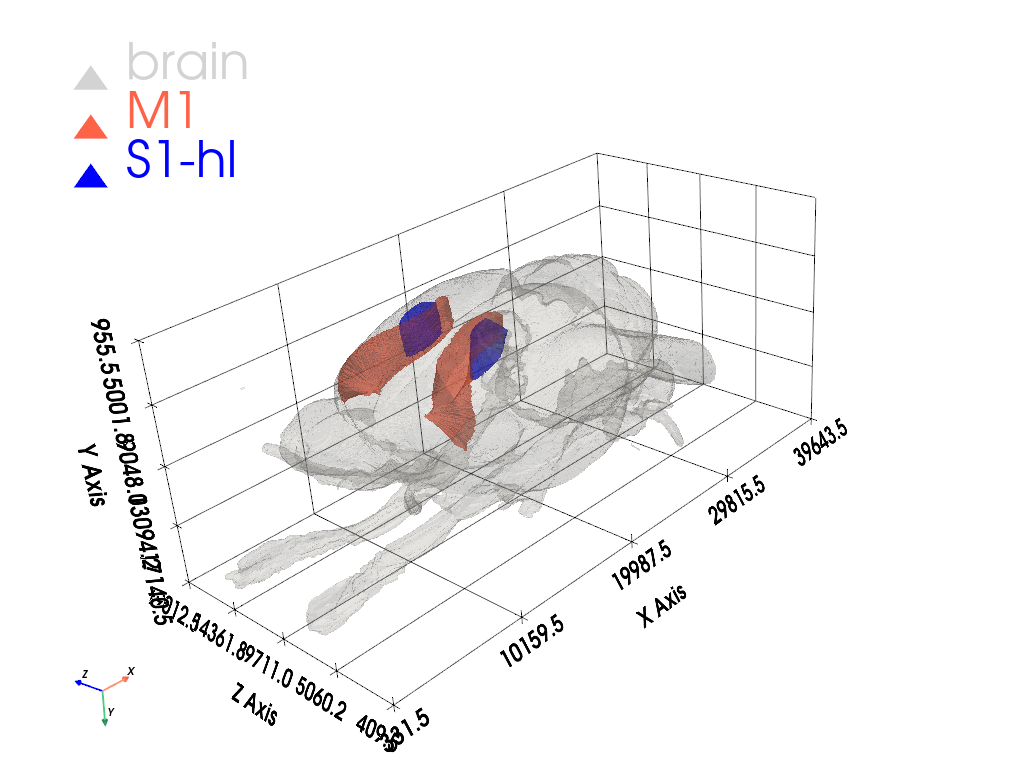

In [125]:
brain_plotter = plot_brain(pv_Full_Brain, pv_Brain_Reg_M1, pv_Brain_Reg_SO, Brain_Reg_M1_name, Brain_Reg_SO_name)
brain_plotter.show(jupyter_backend='static')  # Add this parameter

In [126]:
# plotter.camera_position

# 4. PySonoGen

## 4.1. Create Transducer

In [127]:
import pysonogen.transducers as Transducers

In [128]:
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer']


In [129]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


Transducer initialized in 0.0346 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


In [130]:
# Focalization spot
focus_mm =  np.array([2.3, 0, 6.5])  # mm [x, y, z]

Focus: 2.300 mm, 0.000 mm, 6.500 mm


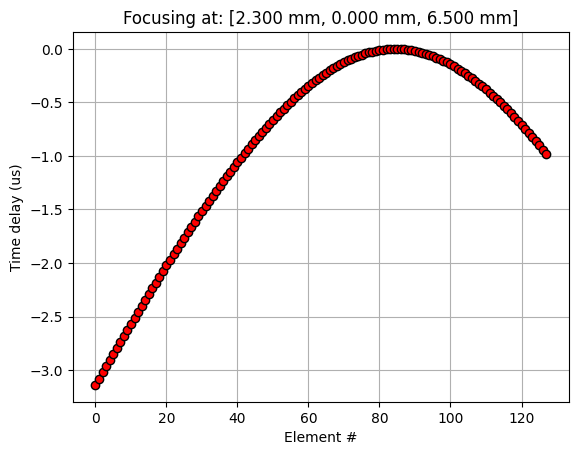

In [131]:
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)

Focus: 2.300 mm, 0.000 mm, 6.500 mm


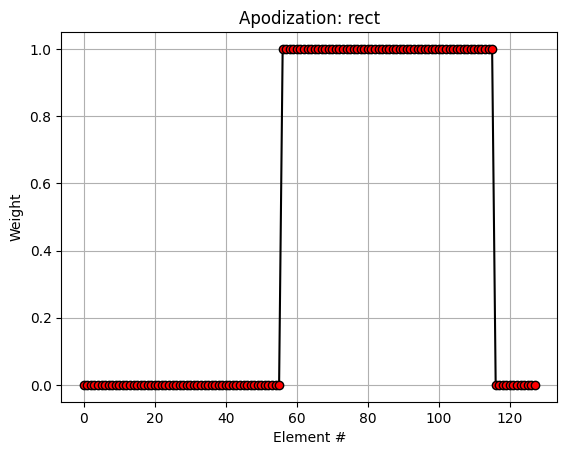

In [132]:
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)

In [134]:
domino.set_apodization(apodization)
domino.set_delays(delays)
domino.show()  # Add this parameter

Widget(value='<iframe src="http://localhost:50297/index.html?ui=P_0x280deb1b140_12&reconnect=auto" class="pyvi…

## 4.1. Compute Pressure Field

In [135]:
from pysonogen import pyfield

In [136]:
Domino_field = pyfield.PyField(domino)


Successfully initialized PyField with 
 LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=rect, tx_N_active=60, F_over_D=1)


In [137]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}

In [138]:
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Creating simulation grid...
Computing spatial impulse response...
Computing all patch events...
Accumulating SIR from events...
Total computation time: 18.4254 seconds.
Computing pressure field...
Original h shape: (512, 68921)
Reshaped h shape: (512, 41, 41, 41)
Performing FFT...
Frequency searched: 12500000.0 Hz. Found: 12328767.123287672 Hz


## 4.3. Visualize pressure field

In [139]:
import pysonogen

Taking slice x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


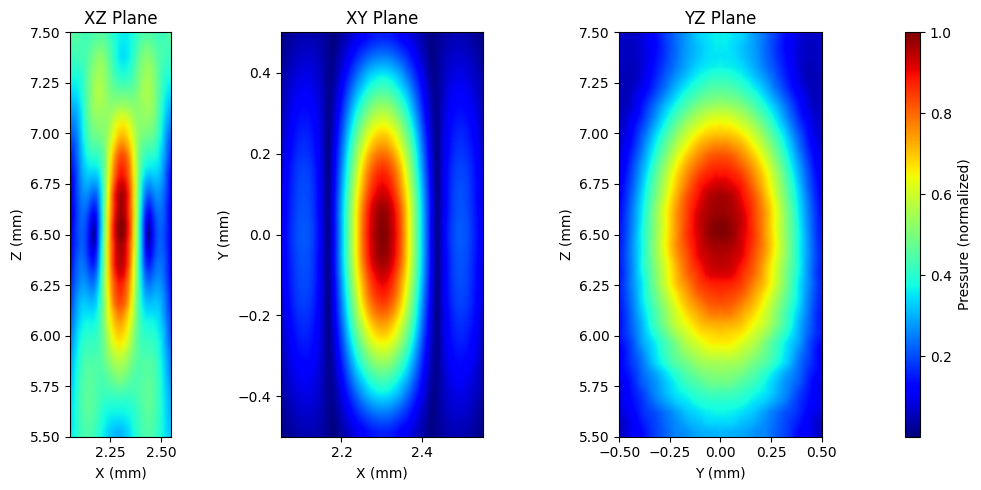

In [140]:
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

One can use customized functions for visualization

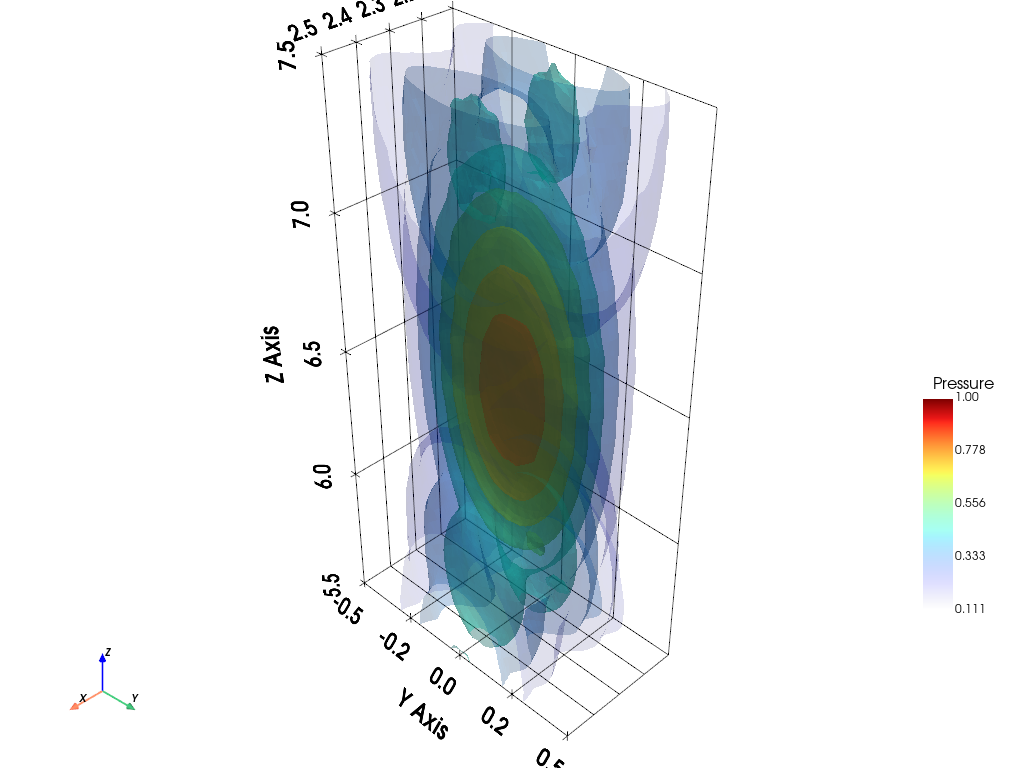

In [141]:
pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True)


pressure_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Overlay Brain and Pressure field

## 5.1. Definition of spaces

When you work with a stack, the origin is the upper left corner when you show the first element stack[0, :, :] with matplotlib or when you open the stack with ImageJ. The first dimension is the one that you are slicing, the second is the height of the image, and the third is the width of the image.

If the origin of your data (first, top left voxel) is the most anterior, superior, left part of the brain, then the orientation string would be “asl” (anterior, superior, left), and you would use asr. The order of the three initials must be the same as the axis order (sliced plane, height, width).

The brain-globe atlas has its orientation in ``asr`` (origin in the Anterior-Superior-Right corner). This means the first x-axis starts in the Anterior and increases towards the Posterior orientation (on the road to cerebellum), the second y-axis stars in the Superior corner and goes towards the Inferior orientation, and the last z-axis starts in the Right and directs towards the Left orientation (pointing to the right hemisphere). 

In adition, each atlas will come with its own resolution and units. In the case of the ``whs_sd_rat_39um`` atlas, the resolution (distance between voxels) is 39um in all direction, and the shape of the stack is (1024, 512, 512) (sliced plane, height, width), which creates then in this orientation axis such us $x \in [0,  39936]\mu m$, $y \in [0,  19968]\mu m$, $x \in [0,  19968]\mu m$,

Take another look to the brain-globe information and image, to verify this information:

In [142]:
print(bg_atlas.space)
bg_atlas.metadata

<BGSpace AnatomicalSpace object>
origin: ('Anterior', 'Superior', 'Right')
sections: ('Frontal plane', 'Horizontal plane', 'Sagittal plane')
shape: (1024, 512, 512)



{'name': 'whs_sd_rat',
 'citation': 'Kleven et al 2023, https://doi.org/10.1038/s41592-023-02034-3',
 'atlas_link': 'https://www.nitrc.org/projects/whs-sd-atlas',
 'species': 'Rattus norvegicus',
 'symmetric': False,
 'resolution': [39.0, 39.0, 39.0],
 'orientation': 'asr',
 'version': '1.2',
 'shape': [1024, 512, 512],
 'trasform_to_bg': [[0.0, -1.0, 0.0, 39936.0],
  [0.0, 0.0, -1.0, 19968.0],
  [-1.0, 0.0, 0.0, 19968.0],
  [0.0, 0.0, 0.0, 1.0]],
 'additional_references': [],
 'atlas_packager': 'Harry Carey, University of Oslo, Norway, harry.carey@medisin.uio.no'}

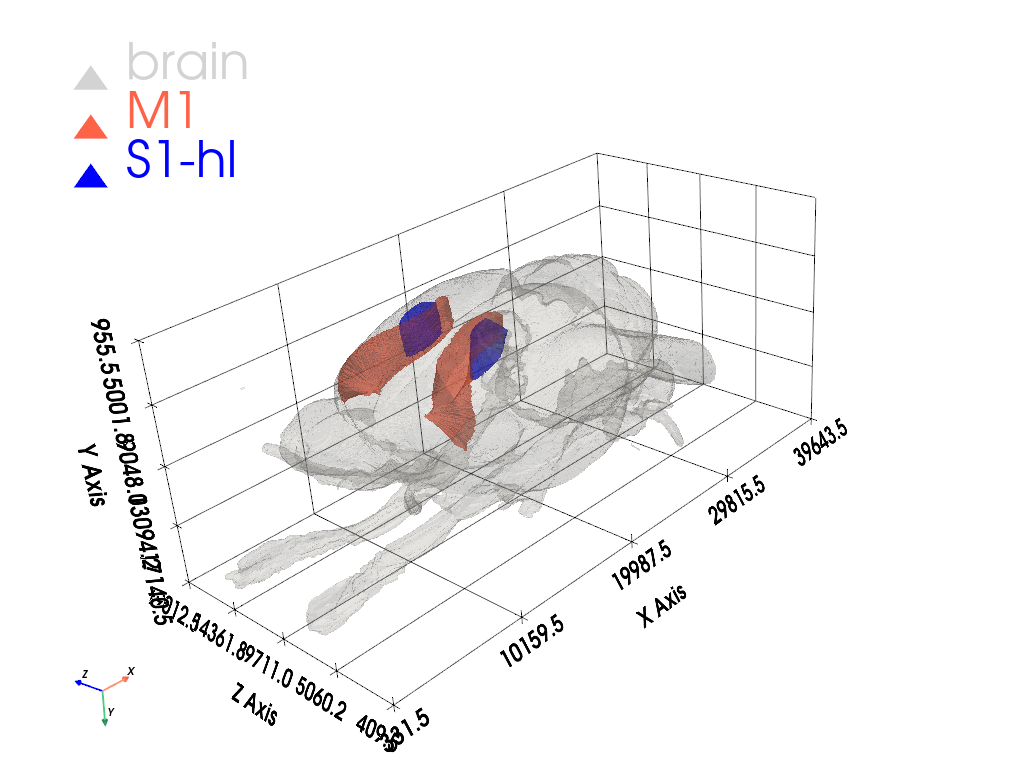

In [143]:
brain_plotter.show(jupyter_backend='static')  # Add this parameter



In our frame work we first need to change the orientation, fUS images are x vs z, and the slices will be stacked over the y direction. There for our orientation will start with the lateral information with the origin on the left hemisphere ``l``, on the most superior part ``s``, and lastly on the anterior ``a`` (front) of the brain. Therefore, our orientation would be ``lsa``. 

Brain globe counts with a module that allow us to compute affine matrix that to define the transformations one must do in a stack of data so one could change the orientation. 

In [144]:
import brainglobe_space as bg_space

In [ ]:
# Now we create the target space 
target_space = bg_space.AnatomicalSpace("ras", resolution=[39*1e3, 39*1e3, 39*1e3],) # New resolution to change the units from um to mm
print(target_space)

<BGSpace AnatomicalSpace object>
origin: ('Right', 'Anterior', 'Superior')
sections: ('Sagittal plane', 'Frontal plane', 'Horizontal plane')
shape: None



From our atlas information, we can compute the matrix to go from our source space to the new target one, to then input it on our pyvista.transform() function.

In [200]:
trans_source2lsa = bg_atlas.space.transformation_matrix_to(target_space)

pv_Full_Brain_changed = pv_Full_Brain.copy()
pv_Full_Brain_changed.transform(trans_source2lsa)
print(f"transformation matrix: \n {trans_source2lsa} ")


transformation matrix: 
 [[0.    0.    0.001 0.   ]
 [0.001 0.    0.    0.   ]
 [0.    0.001 0.    0.   ]
 [0.    0.    0.    1.   ]] 


c:\Users\deyve\Documents\PySonoGen\.venv\Lib\site-packages\pyvista\core\filters\data_object.py:179: PyVistaDeprecationWarning: The default value of `inplace` for the filter `PolyData.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  warnings.warn(msg, PyVistaDeprecationWarning)


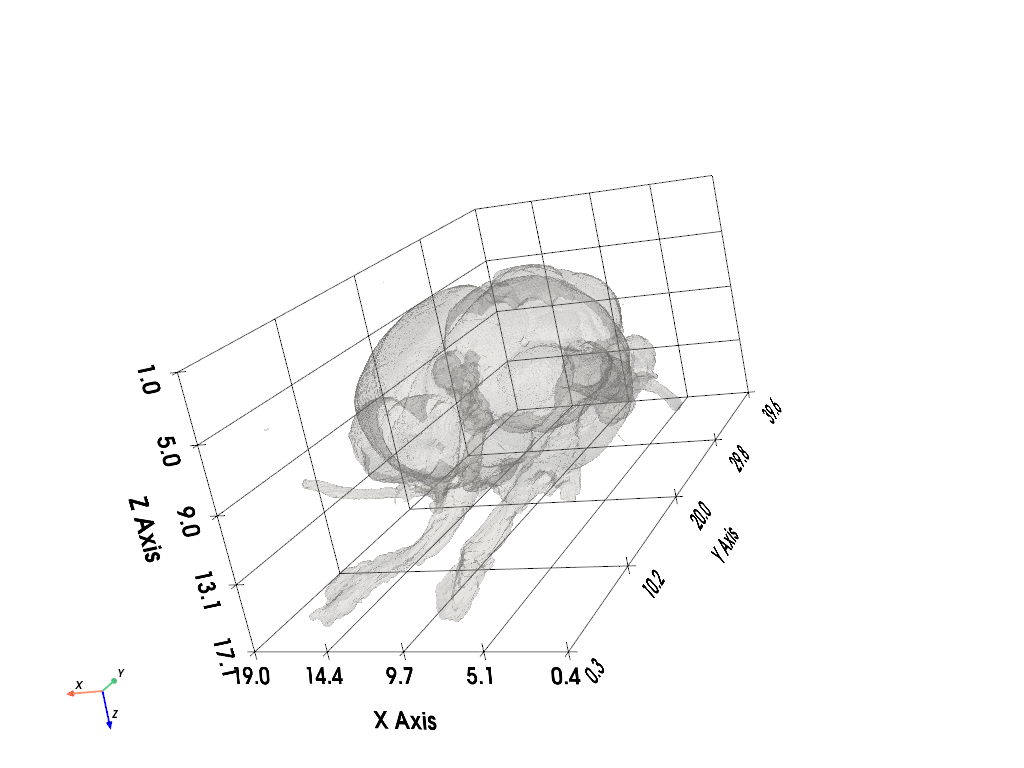

In [191]:

plotter = pv.Plotter(window_size=[1024, 768], title=f"Rat atlas", notebook=True)
plotter.add_mesh(pv_Full_Brain_changed,   color="lightgrey", opacity=0.2,    label="brain")
plotter.add_axes()
plotter.show_grid()
plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
plotter.camera_position = [(-27.363919221794198, -58.16508284096629, -14.498618107592316),
 (9.711, 19.9875, 9.048),
 (-0.07750710293060141, 0.32114273871040966, -0.9438537971364437)]
plotter.show(jupyter_backend='static')  # Add this parameter

In [192]:
def add_transducer_to_plotter(plotter, TX_mesh):
    # Add the transducer to the plotter# 2) Add your TX_mesh with Apodization 
    plotter.add_mesh(TX_mesh, 
        scalars="Apodization",     # use the attached scalar
        cmap="cool",             # color map (you can change to "plasma", "coolwarm", etc.)
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Apodization",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.6,
            "height": 0.3,
        },
        label ="Transducer",  # label for the legend
        color = "purple", # color of the mesh
    )
    return plotter

def add_pressure_to_plotter(plotter, pressure_vol, plot_focal_spot = True):
    # 3) Add the pressure volume
    if plot_focal_spot:
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_field.max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(
            iso_mesh,
            opacity=1.0,
            name="PressureIso",
            show_scalar_bar=False,
            label="Focal Spot",
            color = "r", # color of the mesh
        )
    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_field.max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        plotter.add_mesh(
            iso_mesh,
            scalars="Pressure",  # use the scalar to color surfaces
            cmap="jet",                   # color map
            opacity='linear',                  # solid surfaces
            show_scalar_bar=True,
            scalar_bar_args={"title": "Pressure",
                "vertical": True,
                "title_font_size": 16,
                "label_font_size": 12,
                "position_x": 0.9,
                "position_y": 0.2,
                "height": 0.3,
            },
            label="Pressure PII",
            color = "r", # color of the mesh
    )
    return plotter

We first organize the mesh information

In [193]:
TX_mesh = domino.get_mesh()

# We have already computed the mesh of the pressure field when plotting it with pysonogen functions.
# But in case we want to compute it again, we can use the following function:

# pressure_vol_mesh = pysonogen.compute_pressure_mesh(pressure_field, x, y, z)

In [194]:
plotter = add_transducer_to_plotter(plotter, TX_mesh)
plotter = add_pressure_to_plotter(plotter, pressure_vol_mesh, plot_focal_spot = True)

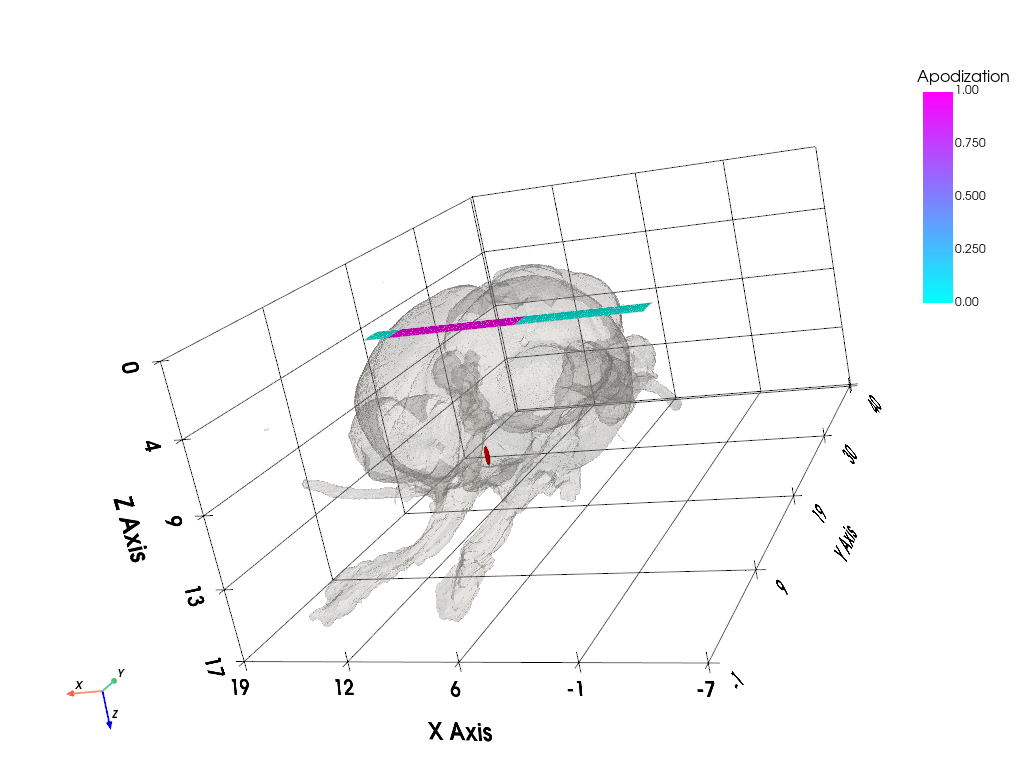

In [197]:
plotter.show(jupyter_backend='dynamic')  # Add this parameter

In [ ]:
region_bounds = pv_region2.bounds
# 1) We create the mesh for the transudcer and the pressure volume

# We create the mesh and flip it to match the coordinate system
# We originally flipped the z axis
TX_mesh = domino.get_mesh()#.flip_z(inplace=True) 
pressure_vol = pressure_vol_mesh#.flip_z(inplace=True) 

# 2) We translate the mesh to the desired position

# We get the initial center of the mesh and the pressure volume
initial_TX_center = np.array(TX_mesh.center)
initial_pressure_center = np.array(pressure_vol_mesh.center)

# We compute the new translation vector of the tranducer
d_btw_tx_brain = 3 # mm
x_tx = 0 # mm
z_tx = - d_btw_tx_brain + min(region_bounds[4], region_bounds[5]) # mm
y_tx = (region_bounds[3]+region_bounds[2])/2 # mm
translation_vector = np.array([x_tx, y_tx, z_tx]) 
print(f"Translation vector : {translation_vector} \n")

# We translate the mesh to the desired position
TX_mesh.translate(translation_vector, inplace=True) # Translate the mesh to the desired position
pressure_vol_mesh.translate(translation_vector, inplace=True)  # Translate the mesh to the desired position
center_tx = np.array(TX_mesh.center)
print(f"TX : {TX_mesh.bounds} \n {center_tx}")
print(f"Pressure : {pressure_vol.bounds} \n {pressure_vol.center}")

TX : BoundsTuple(x_min=-7.039, x_max=7.039, y_min=-0.75, y_max=0.75, z_min=0.0, z_max=0.03523383896300407) 
 (0.0, 0.0, 0.017616919481502034)
Pressure : BoundsTuple(x_min=2.05, x_max=2.550000000000007, y_min=-0.5, y_max=0.5000000000000009, z_min=5.5, z_max=7.499999999999993) 
 (2.3000000000000034, 4.440892098500626e-16, 6.4999999999999964) 
 
Translation vector : [ 0.      4.017  -8.9085] 

TX : BoundsTuple(x_min=-7.039, x_max=7.039, y_min=3.2670000000000003, y_max=4.767, z_min=-8.9085, z_max=-8.873266161036996) 
 [ 0.          4.017      -8.89088308]
Pressure : BoundsTuple(x_min=2.05, x_max=2.550000000000007, y_min=3.5170000000000003, y_max=4.517000000000001, z_min=-3.4085, z_max=-1.4085000000000072) 
 (2.3000000000000034, 4.017000000000001, -2.4085000000000036)


In [ ]:
# Let's center all to the tx
pv_brain.translate(-center_tx, inplace=True)
pv_region.translate(-center_tx, inplace=True)
pv_region2.translate(-center_tx, inplace=True)
pressure_vol.translate(-center_tx, inplace=True)  # Translate the mesh to the desired position
TX_mesh.translate(-center_tx, inplace=True) # Translate the mesh to the desired position


PolyData (0x1745ba3b8e0)
  N Cells:    1280
  N Points:   5120
  N Strips:   0
  X Bounds:   -7.039e+00, 7.039e+00
  Y Bounds:   -7.500e-01, 7.500e-01
  Z Bounds:   -1.762e-02, 1.762e-02
  N Arrays:   1

In [ ]:

# 3. Plot in a standalone Qt window
plot_focal_spot = True

plotter = pv.Plotter(window_size=[1200, 800], title=f"Atlas + {region_name}", notebook=False) #,off_screen=True) # Need to add this parameter to save the screenshot

# 1) Add brain and regions meshes
plotter.add_mesh(pv_brain,   color="lightgrey", opacity=0.2,    label="Brain")
plotter.add_mesh(pv_region,  color="permanentgreen",     opacity=0.6,    label=region_name)
plotter.add_mesh(pv_region2,  color="cadmiumlemon",     opacity=0.6,    label=region_name2)

# 2) Add your TX_mesh with Apodization 
plotter.add_mesh(TX_mesh, 
    scalars="Apodization",     # use the attached scalar
    cmap="cool",             # color map (you can change to "plasma", "coolwarm", etc.)
    show_scalar_bar=True,
    scalar_bar_args={
        "title": "Apodization",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.6,
        "height": 0.3,
    },
    label ="Transducer",  # label for the legend
    color = "purple", # color of the mesh
)

# 3) Add the pressure volume
if plot_focal_spot:
    # pick a threshold, e.g. halfway to the max
    threshold = 0.7 * pressure_field.max()
    iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
    plotter.add_mesh(
        iso_mesh,
        opacity=1.0,
        name="PressureIso",
        show_scalar_bar=False,
        label="Focal Spot",
        color = "r", # color of the mesh
    )
else:
    n_contours = 10
    min_val = 0
    max_val = pressure_field.max()
    levels = np.linspace(min_val, max_val, n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",  # use the scalar to color surfaces
        cmap="jet",                   # color map
        opacity='linear',                  # solid surfaces
        show_scalar_bar=True,
        scalar_bar_args={"title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color = "r", # color of the mesh
    )

plotter.add_axes()              # show XYZ axes
plotter.show_grid()             # show grid
# Force PyVista to recompute near/far clipping so nothing gets inadvertently cut
plotter.reset_camera_clipping_range()
plotter.add_legend(loc = 'upper left')   # show legend
plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
plotter.camera_position = [(-28.698306158203337, 50.0637307486215, -12.962800638572176),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (0.2948778147587468, -0.26283246810551325, -0.9186763130029372)]

plotter.show()  # Add this parameter
# plotter.screenshot(f'RatBrainSonoGenat8mmFocalSpot{plot_focal_spot}.png')


In [ ]:
plotter.camera_position


[(43.1930646065672, 27.876091298924294, -19.921081140767594),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (-0.2768921610289952, -0.49330202856157407, -0.8246113264912924)]

# 5. Make Video

In [ ]:
import pyvista as pv
import numpy as np

# Toggle this to plot the focal spot
plot_focal_spot = True

# Create the plotter in off-screen mode for video
plotter = pv.Plotter(
    window_size=[1200, 800],
    title=f"Atlas + {region_name}",
    notebook=False,
    off_screen=True
)

plotter.set_background("white")

# 1) Add brain and region meshes
plotter.add_mesh(pv_brain, color="lightgrey", opacity=0.2, label="Brain")
plotter.add_mesh(pv_region, color="permanentgreen", opacity=0.6, label=region_name)
plotter.add_mesh(pv_region2, color="cadmiumlemon", opacity=0.6, label=region_name2)

# 2) Add TX_mesh with Apodization
plotter.add_mesh(
    TX_mesh,
    scalars="Apodization",
    cmap="cool",
    show_scalar_bar=True,
    scalar_bar_args={
        "title": "Apodization",
        "vertical": True,
        "title_font_size": 16,
        "label_font_size": 12,
        "position_x": 0.9,
        "position_y": 0.6,
        "height": 0.3,
    },
    label="Transducer",
    color="purple",
)

# 3) Add pressure field
if plot_focal_spot:
    threshold = 0.5 * pressure_field.max()
    iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        opacity=1.0,
        name="PressureIso",
        show_scalar_bar=False,
        label="Focal Spot",
        color="r",
    )
else:
    n_contours = 10
    levels = np.linspace(0, pressure_field.max(), n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",
        cmap="jet",
        opacity='linear',
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color="r",
    )

# Additional visual elements
plotter.add_axes()
plotter.show_grid()
plotter.reset_camera_clipping_range()
plotter.add_legend(loc='upper left')
plotter.camera.up = (0, 0, -1)
plotter.camera_position = [(-20.204850578806113, 57.64176781329657, -2.4115399932513144),
 (-0.9916999658255595, 4.286600862198689, 9.027294494271514),
 (0.0723912778649082, -0.18408613403925303, -0.9802406837831044)]
# Render once before movie to apply camera and settings
plotter.render()

# Open movie file and define frame settings
n_frames = 180
video_filename = "brain_rotation.mp4"
plotter.open_movie(video_filename, framerate=20)

# Rotation loop
plotter.show(auto_close=False)
angle = 0 
for _ in range(n_frames):
    angle += 2  # Degrees to rotate per frame
    plotter.camera.azimuth = angle # Rotate camera
    plotter.render()
    plotter.write_frame()

# Finalize and save
plotter.close()
print(f" Video saved to: {video_filename}")


 Video saved to: brain_rotation.mp4
